# Análisis de Víctimas en Incidentes Viales — Medellín (2014-2021)
### Proyecto — Análisis de datos con Python

**Integrantes:** _(completar nombres)_
**Dataset:** Víctimas en incidentes viales — Secretaría de Movilidad, Alcaldía de Medellín (portal MEData)
**Fuente:** medata.app.medellin.gov.co


## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Leer y explorar el dataset

El archivo viene de MEData, el portal de datos abiertos de la Alcaldía de Medellín.
Cada fila representa una **víctima** de un incidente vial (herido o muerto) entre 2014 y 2021.


In [2]:
df = pd.read_csv("Mede_Victimas_inci.csv", low_memory=False)
print("Filas y columnas:", df.shape)
df.head()


Filas y columnas: (1048317, 19)


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1048317 entries, 0 to 1048316
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Gravedad_victima     235843 non-null  str    
 1   Fecha_incidente      235843 non-null  str    
 2   Hora_incidente       235843 non-null  str    
 3   Clase_incidente      235843 non-null  str    
 4   Direccion_incidente  235831 non-null  str    
 5   Sexo                 235843 non-null  str    
 6   Edad                 235335 non-null  str    
 7   Condicion            235843 non-null  str    
 8   Mes                  235843 non-null  str    
 9   Dia                  235843 non-null  str    
 10  Num_dia              235843 non-null  float64
 11  Hora                 235843 non-null  str    
 12  Grupo_edad           235843 non-null  str    
 13  Año                  235843 non-null  float64
 14  Radicado             235838 non-null  object 
 15  Latitud              23584

## 3. Limpieza de datos

Al explorar el archivo encontramos varios problemas típicos de un export gubernamental:

- Cientos de miles de **filas completamente vacías** al final del archivo (artefacto del export,
  el CSV quedó guardado hasta el límite de filas de Excel).
- **Latitud/Longitud** guardadas como texto con coma decimal (`"6,266..."`) en vez de punto.
- **Sexo** y **Condicion** con inconsistencias de mayúsculas (`Sin Inf` vs `Sin inf`,
  `Acompañante de Motocicleta` vs `Acompañante de motocicleta`).
- El texto **"Sin Inf" / "Sin inf" funciona como un NaN disfrazado** en varias columnas
  (`Sexo`, `Edad`, `Hora`, `Hora_incidente`, `Grupo_edad`, `Comuna`, `Barrio`,
  `Direccion_incidente`, además de `Latitud`/`Longitud`), pero no está marcado como dato
  faltante real — queda como si fuera una categoría más. Lo normalizamos a `NaN` explícito
  en todas las columnas, no solo en las numéricas.
- **Edad** como texto, con el valor `"Sin Inf"` mezclado con números.
- **Fecha_incidente** como texto en vez de fecha.
- Un puñado de filas duplicadas.


In [4]:
# 1) Eliminar filas completamente vacías
print("Filas antes:", df.shape[0])
df = df.dropna(subset=["Gravedad_victima"]).copy()
print("Filas con datos reales:", df.shape[0])


Filas antes: 1048317
Filas con datos reales: 235843


In [5]:
# 2) Eliminar duplicados exactos
print("Duplicados encontrados:", df.duplicated().sum())
df = df.drop_duplicates()
print("Filas después de quitar duplicados:", df.shape[0])


Duplicados encontrados: 197
Filas después de quitar duplicados: 235646


In [ ]:
# 3) Normalizar texto: Sexo y Condicion tienen inconsistencias de mayúsculas/minúsculas
df["Sexo"] = df["Sexo"].replace({"Sin inf": "Sin Inf"})
df["Condicion"] = df["Condicion"].replace({"Acompañante de motocicleta": "Acompañante de Motocicleta"})

df["Latitud"] = pd.to_numeric(df["Latitud"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
df["Longitud"] = pd.to_numeric(df["Longitud"].astype(str).str.replace(",", ".", regex=False), errors="coerce")


In [ ]:
# 4) Edad y Hora a numérico (Sin Inf -> NaN), fecha a datetime
df["Edad"] = pd.to_numeric(df["Edad"], errors="coerce")
df["Hora_num"] = pd.to_numeric(df["Hora"], errors="coerce")
df["Fecha_incidente"] = pd.to_datetime(df["Fecha_incidente"], format="%d/%m/%Y", errors="coerce")
df["Año"] = df["Año"].astype(int)

# 5) "Sin Inf" / "Sin inf" como NaN real en el resto de columnas categóricas
# (en Edad, Hora y las coordenadas ya quedó resuelto arriba al convertir a numérico)
cols_texto_con_sin_inf = [
    "Sexo", "Grupo_edad", "Comuna", "Barrio",
    "Direccion_incidente", "Hora_incidente",
]
for col in cols_texto_con_sin_inf:
    df[col] = df[col].replace({"Sin Inf": np.nan, "Sin inf": np.nan})

print("Nulos tras marcar 'Sin Inf' como NaN:")
print(df[cols_texto_con_sin_inf + ["Edad", "Hora_num", "Latitud", "Longitud"]].isna().sum())

df[["Edad", "Fecha_incidente", "Latitud", "Longitud"]].describe(include="all")


### 3.1 Exportar el dataset depurado

Guardamos el resultado de la limpieza en un CSV aparte. Este es el archivo que debe usarse
como punto de partida en los notebooks de modelos de predicción de cada integrante del
equipo (no se debe repetir la depuración allí).


In [ ]:
df.to_csv("victimas_depuradas.csv", index=False, encoding="utf-8-sig")
print("Dataset depurado exportado a victimas_depuradas.csv")
print("Filas:", df.shape[0], " Columnas:", df.shape[1])


## 4. Análisis: patrones y tendencias

Exploramos cómo se distribuyen las víctimas por año, comuna, tipo de actor vial, hora del día
y día de la semana.


In [8]:
# Víctimas por año y gravedad
por_anio = df.groupby(["Año", "Gravedad_victima"]).size().unstack(fill_value=0)
por_anio


In [9]:
# Top 10 comunas con más víctimas
top_comunas = df["Comuna"].value_counts().head(10)
top_comunas


In [10]:
# Gravedad por tipo de actor vial (Condicion)
tabla = pd.crosstab(df["Condicion"], df["Gravedad_victima"])
tabla["Total"] = tabla.sum(axis=1)
tabla.sort_values("Total", ascending=False)


## 5. Visualización de resultados

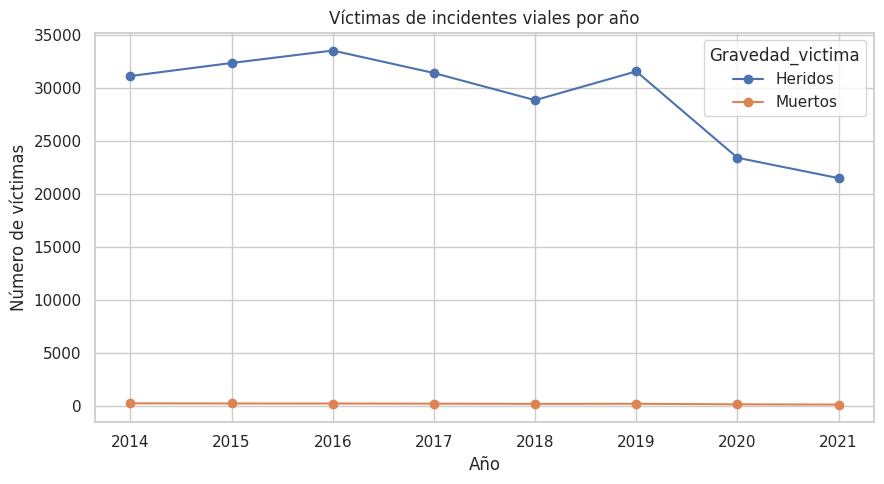

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
por_anio.plot(kind="line", marker="o", ax=ax)
ax.set_title("Víctimas de incidentes viales por año")
ax.set_xlabel("Año")
ax.set_ylabel("Número de víctimas")
plt.tight_layout()
plt.show()


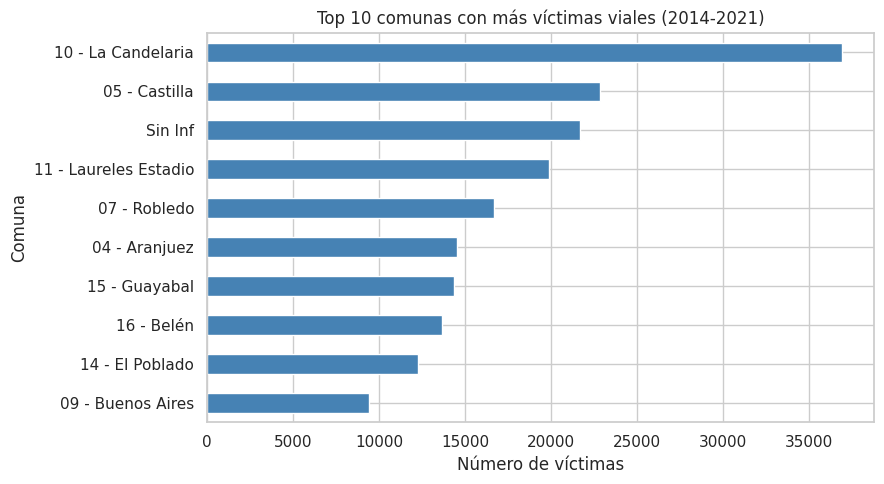

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
top_comunas.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 10 comunas con más víctimas viales (2014-2021)")
ax.set_xlabel("Número de víctimas")
plt.tight_layout()
plt.show()


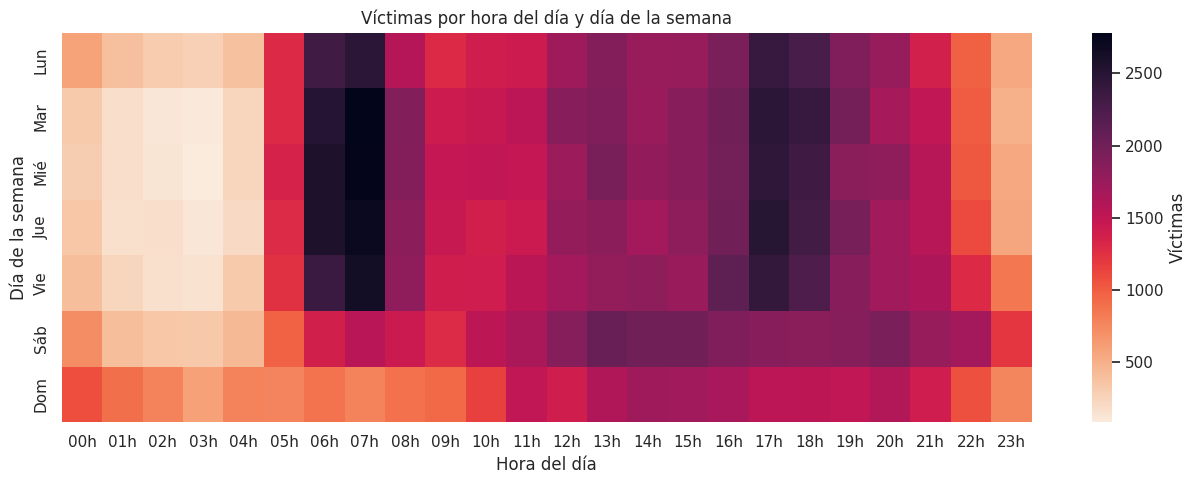

In [13]:
orden_dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
tabla_hd = df.dropna(subset=["Hora_num"]).pivot_table(
    index="Dia", columns="Hora_num", values="Radicado", aggfunc="count", fill_value=0
)
tabla_hd = tabla_hd.reindex(orden_dias)
tabla_hd.columns = [f"{int(h):02d}h" for h in tabla_hd.columns]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(tabla_hd, cmap="rocket_r", ax=ax, cbar_kws={"label": "Víctimas"})
ax.set_title("Víctimas por hora del día y día de la semana")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Día de la semana")
plt.tight_layout()
plt.show()


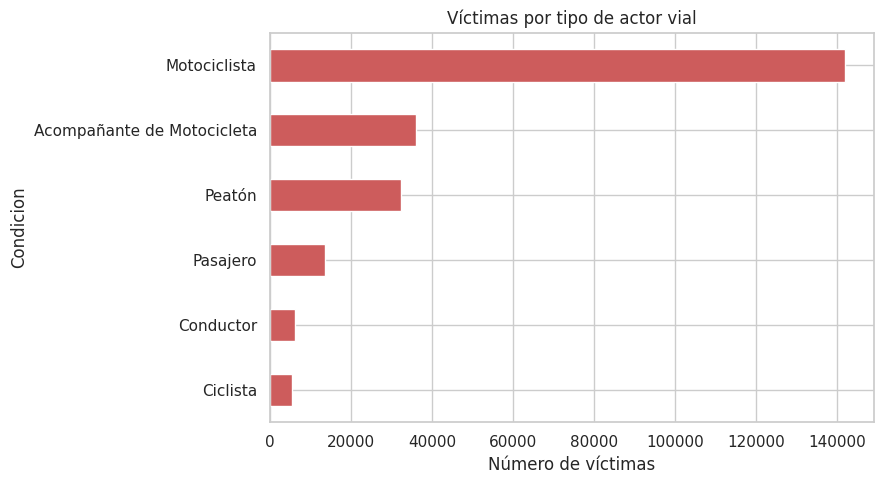

In [14]:
condicion_counts = df["Condicion"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
condicion_counts.sort_values().plot(kind="barh", ax=ax, color="indianred")
ax.set_title("Víctimas por tipo de actor vial")
ax.set_xlabel("Número de víctimas")
plt.tight_layout()
plt.show()


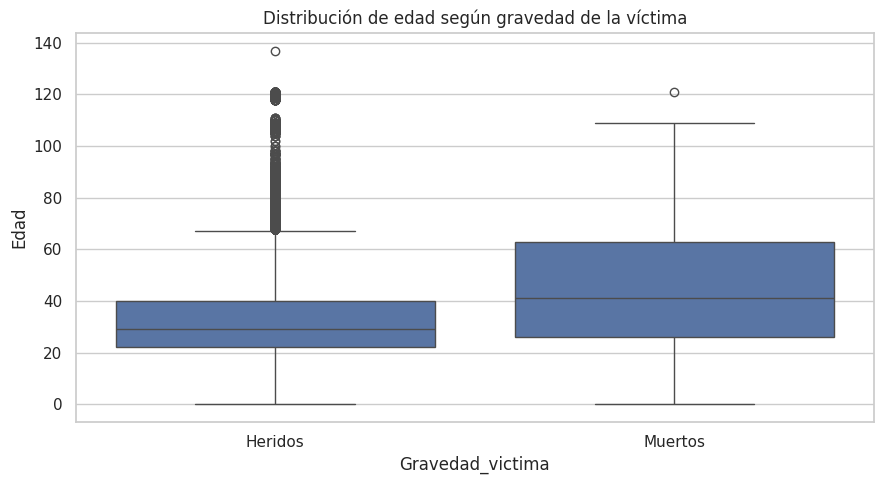

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Gravedad_victima", y="Edad", ax=ax)
ax.set_title("Distribución de edad según gravedad de la víctima")
plt.tight_layout()
plt.show()


## 6. Hallazgos y conclusiones

_(completar y ampliar con base en los resultados obtenidos — estos son puntos de partida)_

- Hallazgo 1: la comuna con más víctimas es **La Candelaria** (centro de la ciudad), probablemente por ser
  la zona de mayor circulación vehicular y peatonal.
- Hallazgo 2: los **motociclistas** concentran la mayor parte de las víctimas viales, muy por encima de peatones,
  ciclistas o conductores de otros vehículos.
- Hallazgo 3: hay una caída notable de víctimas en 2020-2021, coincidiendo con la pandemia y las restricciones
  de movilidad.
- Hallazgo 4: revisar el mapa de calor de hora/día para identificar franjas horarias de mayor riesgo
  (por ejemplo, horas pico).

**Conclusión general:** _(resumir en 2-3 frases qué le dirían a la Secretaría de Movilidad con base en estos datos)_
